   reading  Delta_Change  Pressure  Vibration
0     22.5           0.0       101       0.20
1     23.1           0.6       102       0.22
2     22.8          -0.3       100       0.21
3     24.0           1.2       104       0.25
4     24.3           0.3       105       0.26


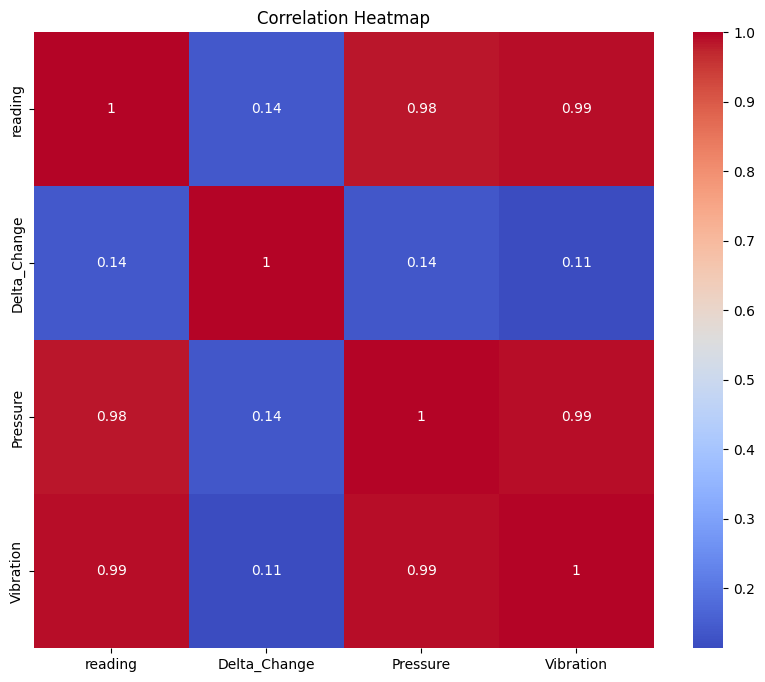


Clusters Created

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


Model Saved Successfully


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# STEP 1: LOAD DATA

df = pd.read_csv('lab_mining_data.csv')
print(df.head())


# STEP 2: CORRELATION ANALYSIS

corr_matrix = df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


# STEP 3: CLUSTERING

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[['reading', 'Delta_Change']]
)

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    random_state=42
)

df['Inherent_Group'] = kmeans.fit_predict(
    X_scaled
)

print("\nClusters Created")


# STEP 4: ANOMALY CREATION

threshold = (
    df['reading'].mean() +
    2 * df['reading'].std()
)

df['Anomaly'] = (
    df['reading'] > threshold
).astype(int)


# STEP 5: CLASSIFICATION

X = df[
    [
        'reading',
        'Delta_Change',
        'Inherent_Group'
    ]
]

y = df['Anomaly']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf.fit(X_train, y_train)


# STEP 6: PREDICTION

y_pred = clf.predict(X_test)

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# STEP 7: SAVE MODEL

joblib.dump(
    clf,
    'lab_mining_model.pkl'
)

print("\nModel Saved Successfully")